# Reading GenBank Files with Jupyter in PyCharm

Ce carnet montre comment lire et extraire des séquences biologiques à partir de fichiers GenBank en utilisant Python. Il est conçu pour fonctionner dans un environnement Jupyter intégré à PyCharm, ce qui le rend idéal pour les débutants en bioinformatique qui explorent l'analyse des données de séquence.


In [1]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction, molecular_weight
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Toutes les bibliothèques importées avec succès!")

Toutes les bibliothèques importées avec succès!


In [2]:
def charger_genbank(fichier_path):
    try:
        record = SeqIO.read(fichier_path, "genbank")
        print(f" Fichier GenBank chargé avec succès!")
        return record
    except Exception as e:
        print(f" Erreur lors du chargement: {e}")
        return None

FICHIER_GENBANK = r"C:\Users\Yassine YH\Downloads\donnees_dakaredu\pasteur_data\sequence.gb"
record = charger_genbank(FICHIER_GENBANK)

if record:
    print("\n" + "="*60)
    print(" INFORMATIONS GÉNÉRALES DU GÉNOME")
    print("="*60)
    print(f"ID: {record.id}")
    print(f"Nom: {record.name}")
    print(f"Description: {record.description}")
    print(f"Longueur: {len(record.seq):,} bp")
    print(f"Topologie: {record.annotations.get('topology', 'Non spécifiée')}")
    print(f"Type de molécule: {record.annotations.get('molecule_type', 'Non spécifié')}")
    print(f"Organisme: {record.annotations.get('organism', 'Non spécifié')}")
    print(f"% GC: {gc_fraction(record.seq):.2f}%")

 Fichier GenBank chargé avec succès!

 INFORMATIONS GÉNÉRALES DU GÉNOME
ID: NC_000913.3
Nom: NC_000913
Description: Escherichia coli str. K-12 substr. MG1655, complete genome
Longueur: 4,641,652 bp
Topologie: circular
Type de molécule: DNA
Organisme: Escherichia coli str. K-12 substr. MG1655
% GC: 0.51%


In [3]:
def analyser_metadonnees(record):

    print("\n" + "="*60)
    print(" MÉTADONNÉES DÉTAILLÉES")
    print("="*60)

    annotations_cles = ['source', 'organism', 'taxonomy', 'references',
                       'comment', 'keywords', 'accessions']

    for key, value in record.annotations.items():
        if key in ['references']:
            print(f"\n {key.upper()}:")
            for i, ref in enumerate(value, 1):
                print(f"  Référence {i}: {ref.title}")
                print(f"    Auteurs: {ref.authors}")
                print(f"    Journal: {ref.journal}")
        elif isinstance(value, list):
            print(f"{key}: {', '.join(map(str, value))}")
        else:
            print(f"{key}: {value}")

    print(f"\n ANALYSE DES FEATURES:")
    feature_counts = defaultdict(int)
    for feature in record.features:
        feature_counts[feature.type] += 1

    for feature_type, count in sorted(feature_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feature_type}: {count:,}")

    return feature_counts

if record:
    feature_stats = analyser_metadonnees(record)


 MÉTADONNÉES DÉTAILLÉES
molecule_type: DNA
topology: circular
data_file_division: CON
date: 09-MAR-2022
accessions: NC_000913
sequence_version: 3
keywords: RefSeq
source: Escherichia coli str. K-12 substr. MG1655
organism: Escherichia coli str. K-12 substr. MG1655
taxonomy: Bacteria, Pseudomonadati, Pseudomonadota, Gammaproteobacteria, Enterobacterales, Enterobacteriaceae, Escherichia

 REFERENCES:
  Référence 1: Escherichia coli K-12: a cooperatively developed annotation snapshot--2005
    Auteurs: Riley,M., Abe,T., Arnaud,M.B., Berlyn,M.K., Blattner,F.R., Chaudhuri,R.R., Glasner,J.D., Horiuchi,T., Keseler,I.M., Kosuge,T., Mori,H., Perna,N.T., Plunkett,G. III, Rudd,K.E., Serres,M.H., Thomas,G.H., Thomson,N.R., Wishart,D. and Wanner,B.L.
    Journal: Nucleic Acids Res. 34 (1), 1-9 (2006)
  Référence 2: Highly accurate genome sequences of Escherichia coli K-12 strains MG1655 and W3110
    Auteurs: Hayashi,K., Morooka,N., Yamamoto,Y., Fujita,K., Isono,K., Choi,S., Ohtsubo,E., Baba,T., W

In [4]:
def extraire_cds_ecoli(record):

    print("\n" + "="*60)
    print(" EXTRACTION DES SÉQUENCES CODANTES (CDS)")
    print("="*60)

    cds_list = []
    problemes = []

    for i, feature in enumerate(record.features):
        if feature.type == "CDS":
            try:
                cds_info = {
                    'index': i,
                    'start': int(feature.location.start) + 1,
                    'end': int(feature.location.end),
                    'strand': '+' if feature.location.strand == 1 else '-',
                    'length_bp': len(feature.location),
                }

                qualifiers = feature.qualifiers
                cds_info['gene'] = qualifiers.get('gene', ['Unknown'])[0]
                cds_info['locus_tag'] = qualifiers.get('locus_tag', ['Unknown'])[0]
                cds_info['product'] = qualifiers.get('product', ['Unknown'])[0]
                cds_info['protein_id'] = qualifiers.get('protein_id', ['Unknown'])[0]
                cds_info['gene_synonym'] = qualifiers.get('gene_synonym', [''])[0]
                cds_info['codon_start'] = int(qualifiers.get('codon_start', ['1'])[0])
                cds_info['transl_table'] = int(qualifiers.get('transl_table', ['11'])[0])

                dna_seq = feature.extract(record.seq)
                cds_info['dna_sequence'] = str(dna_seq)

                cds_info['length_aa'] = (cds_info['length_bp'] - 3) // 3
                cds_info['gc_content'] = gc_fraction(dna_seq)

                if 'translation' in qualifiers:
                    protein_seq = qualifiers['translation'][0]
                else:
                    protein_seq = str(dna_seq.translate(table=11, stop_symbol='*'))

                cds_info['protein_sequence'] = protein_seq.rstrip('*')
                cds_info['actual_length_aa'] = len(cds_info['protein_sequence'])

                if cds_info['protein_sequence'] and len(cds_info['protein_sequence']) > 0:
                    try:
                        prot_analysis = ProteinAnalysis(cds_info['protein_sequence'])
                        cds_info['molecular_weight'] = prot_analysis.molecular_weight()
                        cds_info['isoelectric_point'] = prot_analysis.isoelectric_point()
                    except:
                        cds_info['molecular_weight'] = len(cds_info['protein_sequence']) * 110
                        cds_info['isoelectric_point'] = 0

                cds_list.append(cds_info)

            except Exception as e:
                problemes.append(f"CDS {i}: {str(e)}")

    print(f" {len(cds_list):,} CDS extraites avec succès")
    if problemes:
        print(f"️ {len(problemes)} problèmes rencontrés:")
        for prob in problemes[:5]:
            print(f"   {prob}")

    return cds_list

if record:
    cds_sequences = extraire_cds_ecoli(record)


 EXTRACTION DES SÉQUENCES CODANTES (CDS)
 4,315 CDS extraites avec succès


In [5]:
def analyser_statistiques_proteines(cds_list):

    print("\n" + "="*60)
    print(" STATISTIQUES DES PROTÉINES")
    print("="*60)

    df = pd.DataFrame(cds_list)

    print(f"Nombre total de CDS: {len(df):,}")
    print(f"Nombre de gènes nommés: {len(df[df['gene'] != 'Unknown']):,}")
    print(f"Nombre de protéines hypothétiques: {len(df[df['product'].str.contains('hypothetical', case=False, na=False)]):,}")

    print(f"\n LONGUEURS DES PROTÉINES:")
    print(f"Longueur moyenne: {df['actual_length_aa'].mean():.1f} acides aminés")
    print(f"Longueur médiane: {df['actual_length_aa'].median():.1f} acides aminés")
    print(f"Longueur min: {df['actual_length_aa'].min()} aa")
    print(f"Longueur max: {df['actual_length_aa'].max()} aa")
    print(f"Écart-type: {df['actual_length_aa'].std():.1f} aa")

    df_valid_mw = df[df['molecular_weight'] > 0]
    print(f"\n POIDS MOLÉCULAIRES:")
    print(f"Poids moyen: {df_valid_mw['molecular_weight'].mean():.0f} Da")
    print(f"Poids médian: {df_valid_mw['molecular_weight'].median():.0f} Da")
    print(f"Poids min: {df_valid_mw['molecular_weight'].min():.0f} Da")
    print(f"Poids max: {df_valid_mw['molecular_weight'].max():.0f} Da")

    df_valid_pi = df[df['isoelectric_point'] > 0]
    print(f"\n POINTS ISOÉLECTRIQUES:")
    print(f"pI moyen: {df_valid_pi['isoelectric_point'].mean():.2f}")
    print(f"pI médian: {df_valid_pi['isoelectric_point'].median():.2f}")

    print(f"\n CONTENU GC DES CDS:")
    print(f"GC moyen: {df['gc_content'].mean():.2f}%")
    print(f"GC médian: {df['gc_content'].median():.2f}%")

    print(f"\n TOP 10 DES PLUS LONGUES PROTÉINES:")
    top_proteins = df.nlargest(10, 'actual_length_aa')[['gene', 'locus_tag', 'product', 'actual_length_aa', 'molecular_weight']]
    print(top_proteins.to_string(index=False))

    return df

if record and cds_sequences:
    df_proteines = analyser_statistiques_proteines(cds_sequences)


 STATISTIQUES DES PROTÉINES
Nombre total de CDS: 4,315
Nombre de gènes nommés: 4,315
Nombre de protéines hypothétiques: 0

 LONGUEURS DES PROTÉINES:
Longueur moyenne: 310.0 acides aminés
Longueur médiane: 274.0 acides aminés
Longueur min: 8 aa
Longueur max: 2358 aa
Écart-type: 212.6 aa

 POIDS MOLÉCULAIRES:
Poids moyen: 34336 Da
Poids médian: 30423 Da
Poids min: 915 Da
Poids max: 248566 Da

 POINTS ISOÉLECTRIQUES:
pI moyen: 6.94
pI médian: 6.20

 CONTENU GC DES CDS:
GC moyen: 0.51%
GC médian: 0.52%

 TOP 10 DES PLUS LONGUES PROTÉINES:
gene locus_tag                                              product  actual_length_aa  molecular_weight
yeeJ     b1978                      inverse autotransporter adhesin              2358       248566.2464
ydbA     b4492 putative outer membrane protein, N-terminal fragment              2020       207692.3960
yfhM     b2520                                 alpha2-macroglobulin              1653       181583.1574
 lhr     b1653                           A


CRÉATION DES VISUALISATIONS


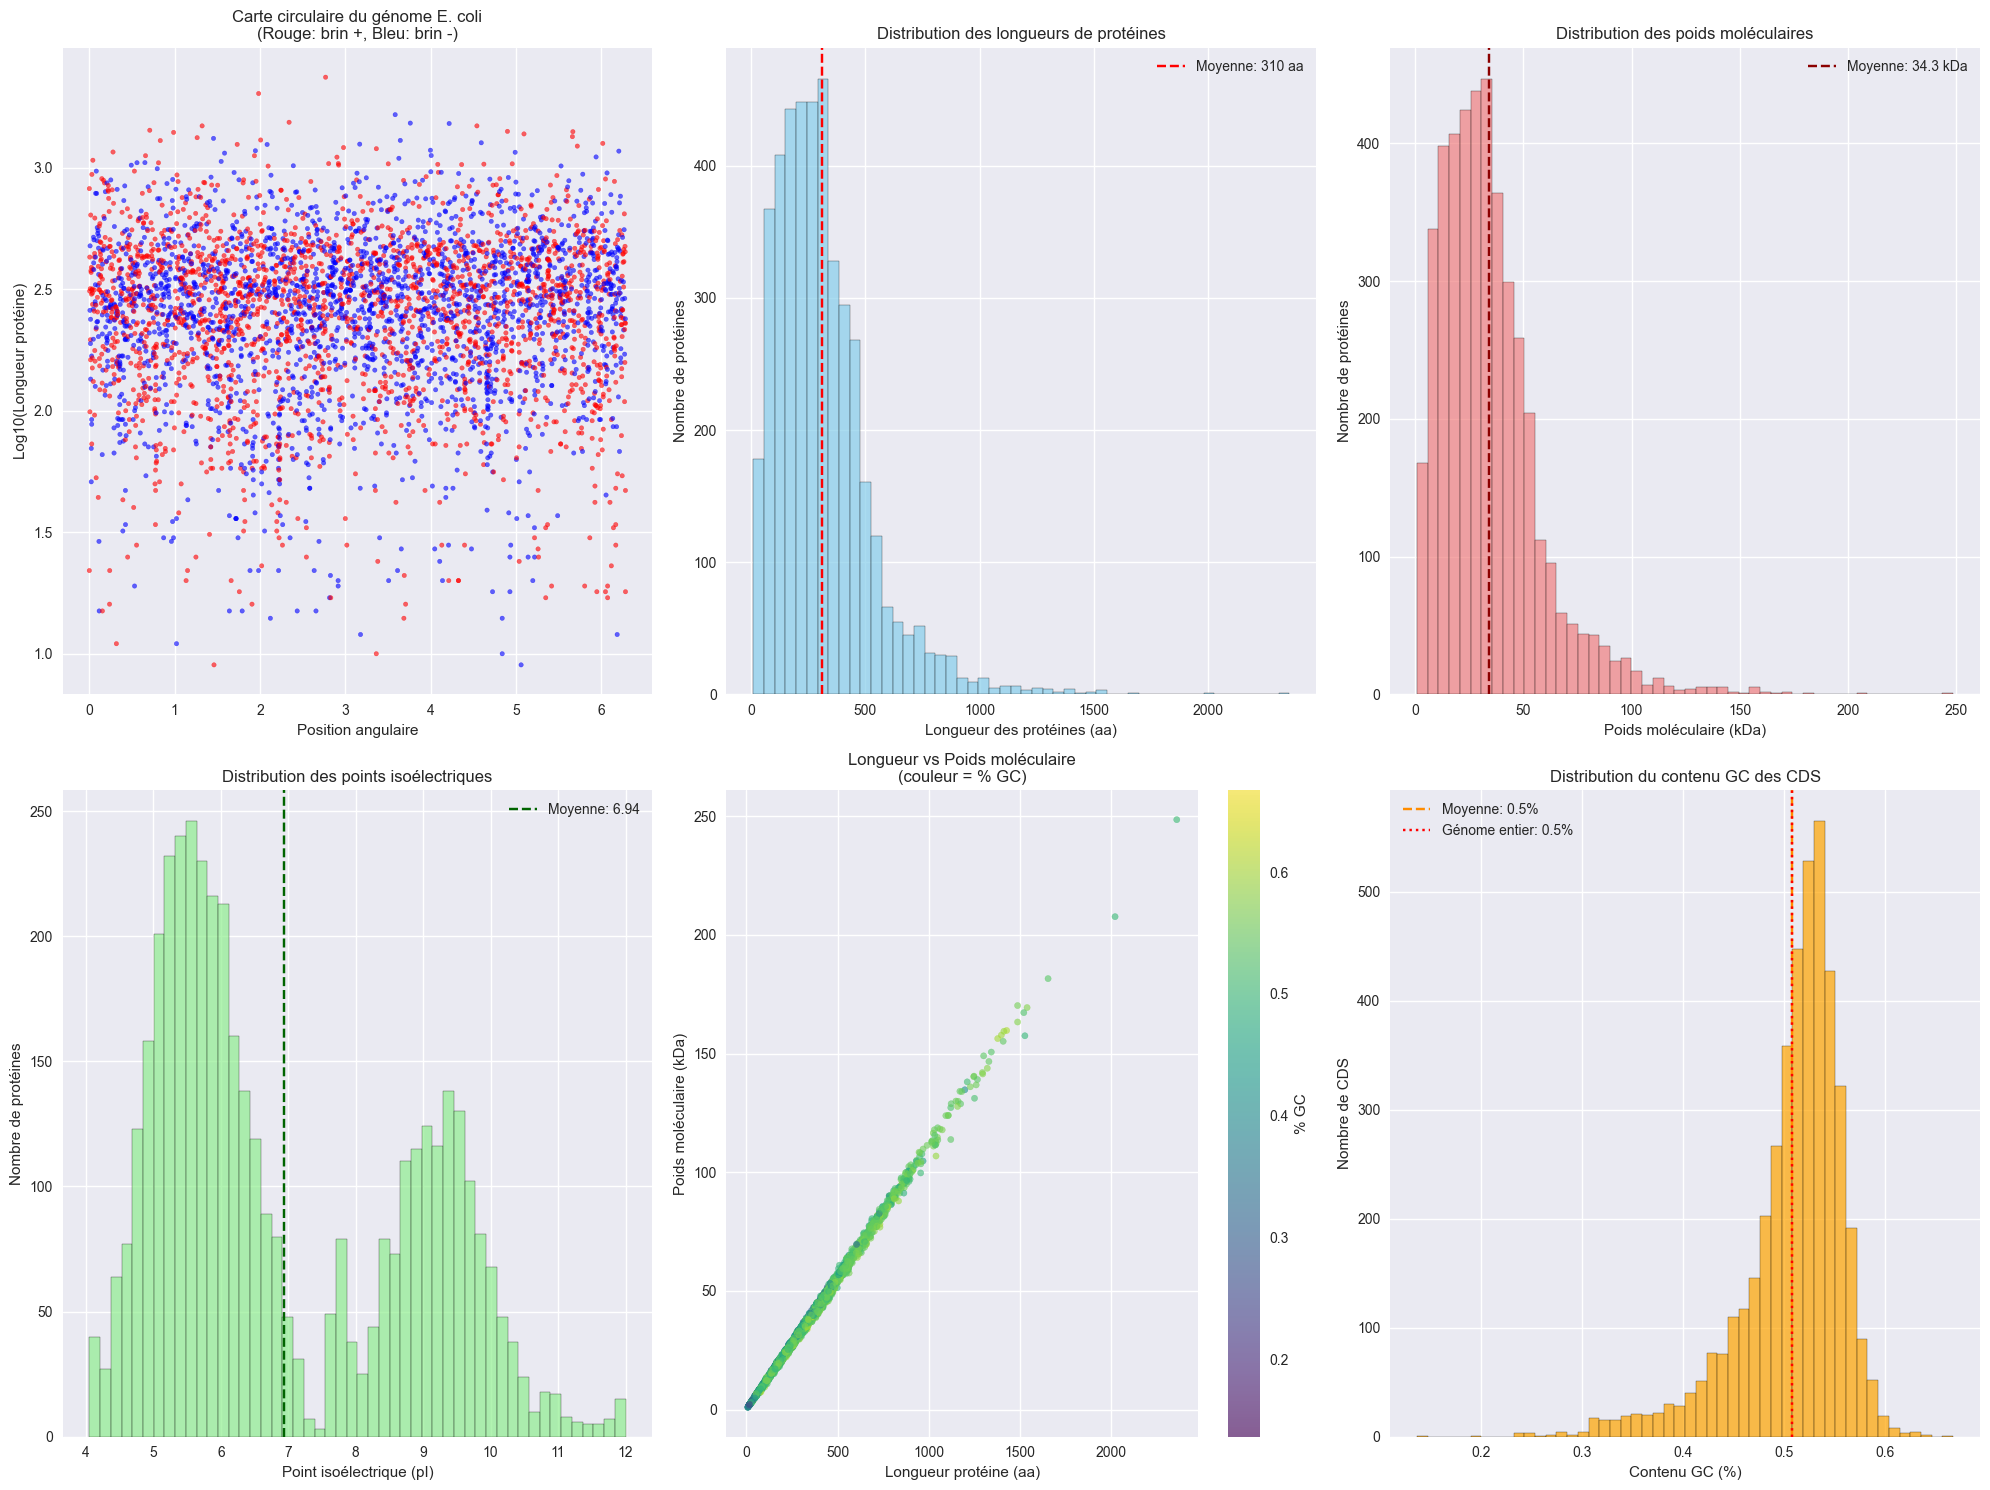

In [6]:
def creer_visualisations_ecoli(record, df_proteines):
    """Crée des visualisations complètes pour E. coli"""

    print("\n" + "="*60)
    print("CRÉATION DES VISUALISATIONS")
    print("="*60)

    fig = plt.figure(figsize=(20, 15))

    ax1 = plt.subplot(2, 3, 1)

    angles = np.linspace(0, 2*np.pi, len(df_proteines), endpoint=False)
    positions = df_proteines['start'].values / len(record.seq) * 2 * np.pi
    lengths = np.log10(df_proteines['actual_length_aa'].values + 1)

    colors = ['red' if strand == '+' else 'blue' for strand in df_proteines['strand']]

    ax1.scatter(positions, lengths, c=colors, alpha=0.6, s=10)
    ax1.set_title('Carte circulaire du génome E. coli\n(Rouge: brin +, Bleu: brin -)', fontsize=12)
    ax1.set_xlabel('Position angulaire')
    ax1.set_ylabel('Log10(Longueur protéine)')

    ax2 = plt.subplot(2, 3, 2)
    ax2.hist(df_proteines['actual_length_aa'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.set_xlabel('Longueur des protéines (aa)')
    ax2.set_ylabel('Nombre de protéines')
    ax2.set_title('Distribution des longueurs de protéines')
    ax2.axvline(df_proteines['actual_length_aa'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_proteines["actual_length_aa"].mean():.0f} aa')
    ax2.legend()

    ax3 = plt.subplot(2, 3, 3)
    valid_mw = df_proteines[df_proteines['molecular_weight'] > 0]['molecular_weight']
    ax3.hist(valid_mw/1000, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    ax3.set_xlabel('Poids moléculaire (kDa)')
    ax3.set_ylabel('Nombre de protéines')
    ax3.set_title('Distribution des poids moléculaires')
    ax3.axvline(valid_mw.mean()/1000, color='darkred', linestyle='--', label=f'Moyenne: {valid_mw.mean()/1000:.1f} kDa')
    ax3.legend()

    ax4 = plt.subplot(2, 3, 4)
    valid_pi = df_proteines[df_proteines['isoelectric_point'] > 0]['isoelectric_point']
    ax4.hist(valid_pi, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    ax4.set_xlabel('Point isoélectrique (pI)')
    ax4.set_ylabel('Nombre de protéines')
    ax4.set_title('Distribution des points isoélectriques')
    ax4.axvline(valid_pi.mean(), color='darkgreen', linestyle='--', label=f'Moyenne: {valid_pi.mean():.2f}')
    ax4.legend()

    ax5 = plt.subplot(2, 3, 5)
    valid_data = df_proteines[df_proteines['molecular_weight'] > 0]
    scatter = ax5.scatter(valid_data['actual_length_aa'], valid_data['molecular_weight']/1000,
                         alpha=0.6, c=valid_data['gc_content'], cmap='viridis', s=20)
    ax5.set_xlabel('Longueur protéine (aa)')
    ax5.set_ylabel('Poids moléculaire (kDa)')
    ax5.set_title('Longueur vs Poids moléculaire\n(couleur = % GC)')
    plt.colorbar(scatter, ax=ax5, label='% GC')

    ax6 = plt.subplot(2, 3, 6)
    ax6.hist(df_proteines['gc_content'], bins=50, alpha=0.7, color='orange', edgecolor='black')
    ax6.set_xlabel('Contenu GC (%)')
    ax6.set_ylabel('Nombre de CDS')
    ax6.set_title('Distribution du contenu GC des CDS')
    ax6.axvline(df_proteines['gc_content'].mean(), color='darkorange', linestyle='--',
               label=f'Moyenne: {df_proteines["gc_content"].mean():.1f}%')
    ax6.axvline(gc_fraction(record.seq), color='red', linestyle=':', label=f'Génome entier: {gc_fraction(record.seq):.1f}%')
    ax6.legend()

    plt.tight_layout()
    plt.show()

    return fig

if record and 'df_proteines' in locals():
    fig_viz = creer_visualisations_ecoli(record, df_proteines)


🔬 ANALYSE FONCTIONNELLE
 CATÉGORIES FONCTIONNELLES:
  Métabolisme: 861 (20.0%)
  Hypothétiques: 791 (18.3%)
  Transport: 479 (11.1%)
  Réplication/Réparation: 396 (9.2%)
  Régulation: 370 (8.6%)
  Structure/Motilité: 157 (3.6%)
  Stress/Défense: 132 (3.1%)

 TOP 15 DES FONCTIONS LES PLUS FRÉQUENTES:
   1. IS5 family transposase and trans-activator (12)
   2. putative inner membrane protein (10)
   3. IS1 family protein InsB (6)
   4. IS1 family protein InsA (6)
   5. IS2 insertion element protein InsB (5)
   6. IS3 element protein InsE (5)
   7. IS3 element protein InsF (5)
   8. IS2 insertion element repressor InsA (5)
   9. inner membrane protein (3)
  10. putative integrase (3)
  11. IS30 family transposase (3)
  12. translation initiation factor IF-2beta' (3)
  13. NAD(P)H:quinone oxidoreductase (2)
  14. putative oxidoreductase (2)
  15. undecaprenyl pyrophosphate phosphatase (2)


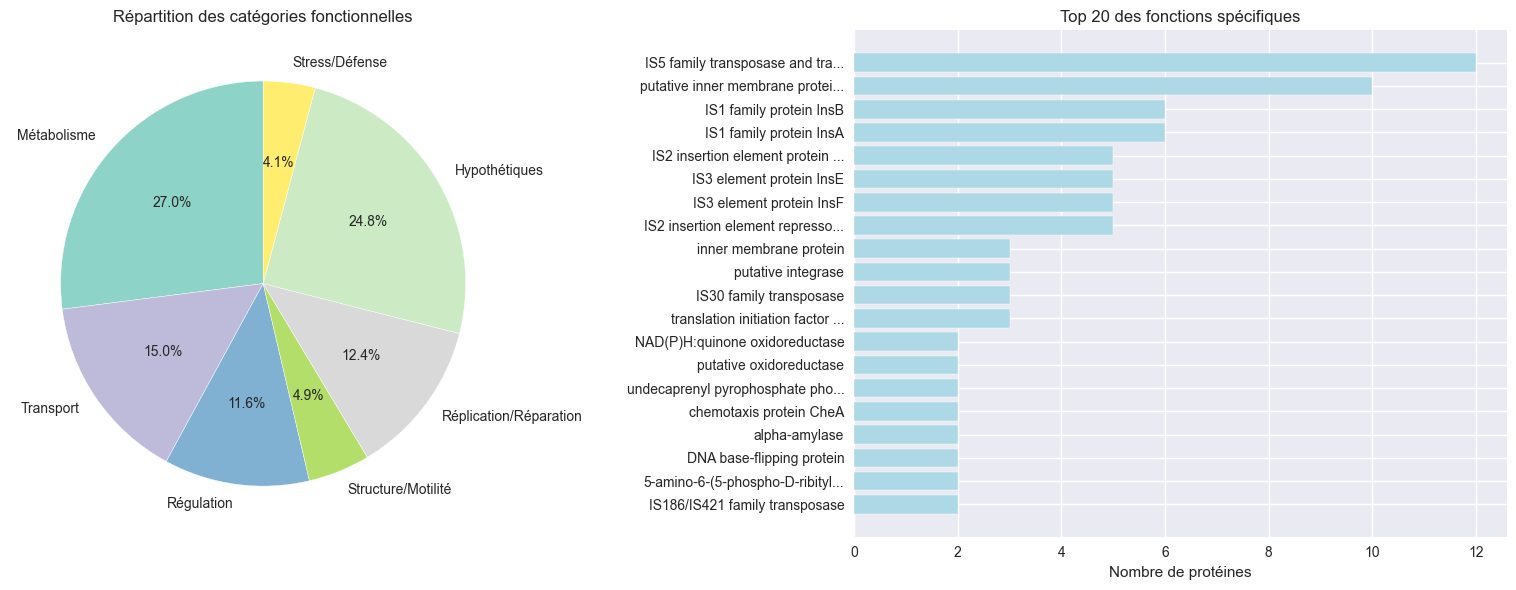

In [7]:
def analyser_fonctions_ecoli(df_proteines):

    print("\n" + "="*60)
    print("🔬 ANALYSE FONCTIONNELLE")
    print("="*60)

    products = df_proteines['product'].str.lower()

    categories_fonctionnelles = {
        'Métabolisme': ['dehydrogenase', 'synthase', 'reductase', 'oxidase', 'kinase', 'transferase'],
        'Transport': ['transporter', 'permease', 'channel', 'pump', 'porter'],
        'Régulation': ['regulator', 'activator', 'repressor', 'sigma', 'response'],
        'Structure/Motilité': ['ribosomal', 'flagellar', 'pilus', 'fimbrial', 'structural'],
        'Réplication/Réparation': ['dna', 'replication', 'repair', 'recombination', 'polymerase'],
        'Hypothétiques': ['hypothetical', 'predicted', 'putative', 'uncharacterized'],
        'Stress/Défense': ['stress', 'resistance', 'toxin', 'antitoxin', 'chaperone']
    }

    category_counts = {}
    for category, keywords in categories_fonctionnelles.items():
        count = sum(products.str.contains('|'.join(keywords), case=False, na=False))
        category_counts[category] = count

    product_counts = df_proteines['product'].value_counts()

    print(f" CATÉGORIES FONCTIONNELLES:")
    for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / len(df_proteines)) * 100
        print(f"  {category}: {count:,} ({percentage:.1f}%)")

    print(f"\n TOP 15 DES FONCTIONS LES PLUS FRÉQUENTES:")
    for i, (product, count) in enumerate(product_counts.head(15).items(), 1):
        print(f"  {i:2d}. {product[:60]}{'...' if len(product) > 60 else ''} ({count})")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    categories = list(category_counts.keys())
    values = list(category_counts.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))

    ax1.pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
    ax1.set_title('Répartition des catégories fonctionnelles')

    top_20 = product_counts.head(20)
    ax2.barh(range(len(top_20)), top_20.values, color='lightblue')
    ax2.set_yticks(range(len(top_20)))
    ax2.set_yticklabels([f"{func[:30]}..." if len(func) > 30 else func for func in top_20.index])
    ax2.set_xlabel('Nombre de protéines')
    ax2.set_title('Top 20 des fonctions spécifiques')
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()

    return category_counts, product_counts

if 'df_proteines' in locals():
    categories, fonctions = analyser_fonctions_ecoli(df_proteines)


 Création carte génomique détaillée (région 0-100,000 bp)


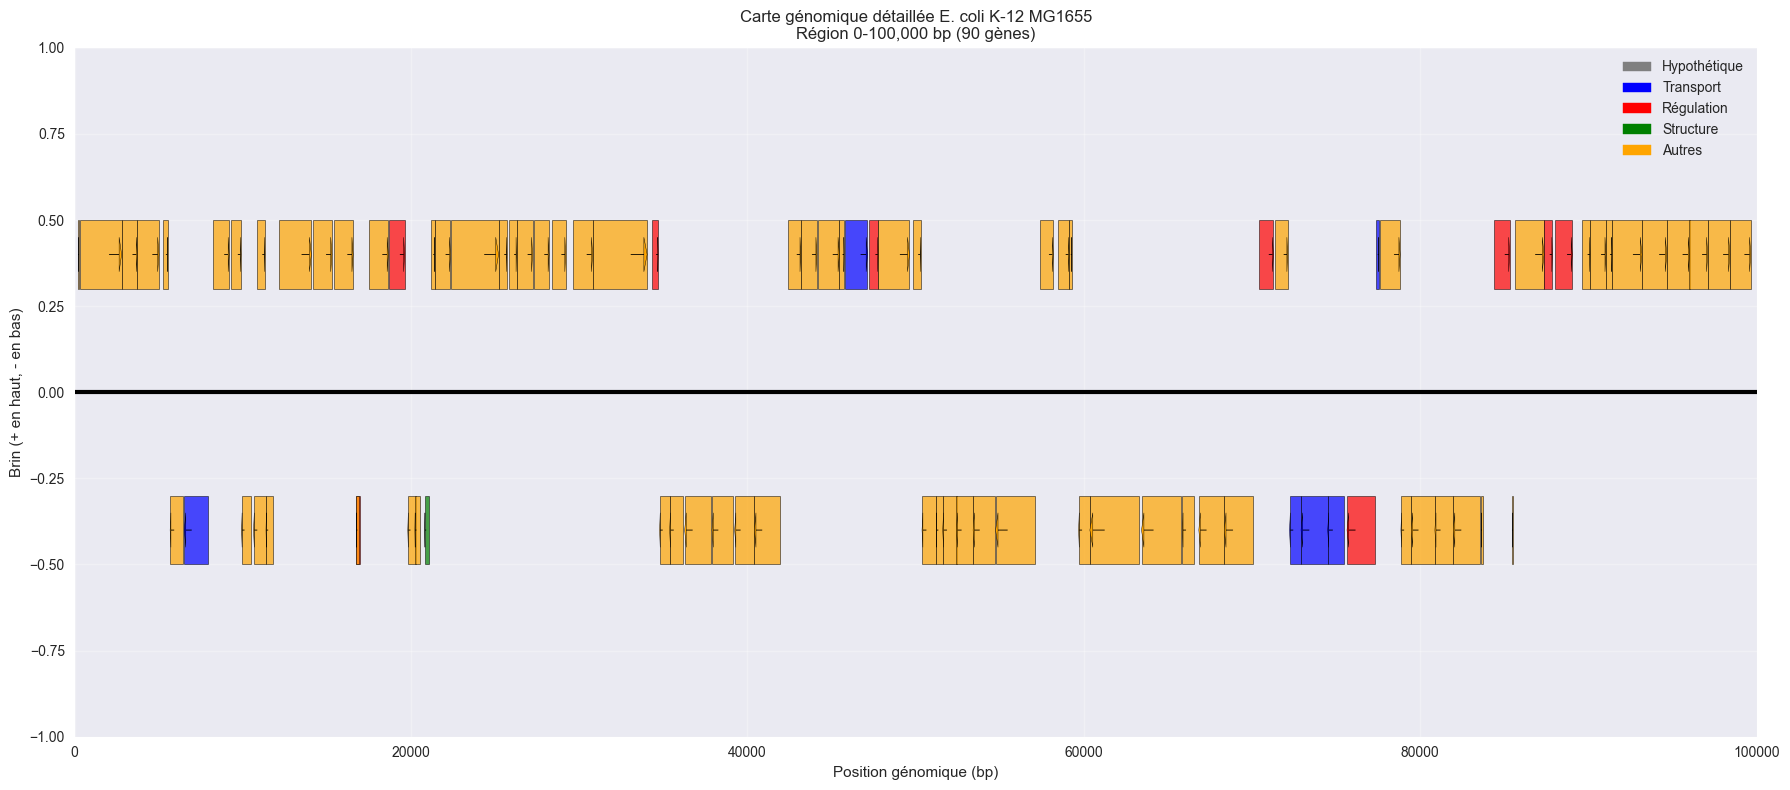


 Création carte génomique détaillée (région 2,270,826-2,370,826 bp)


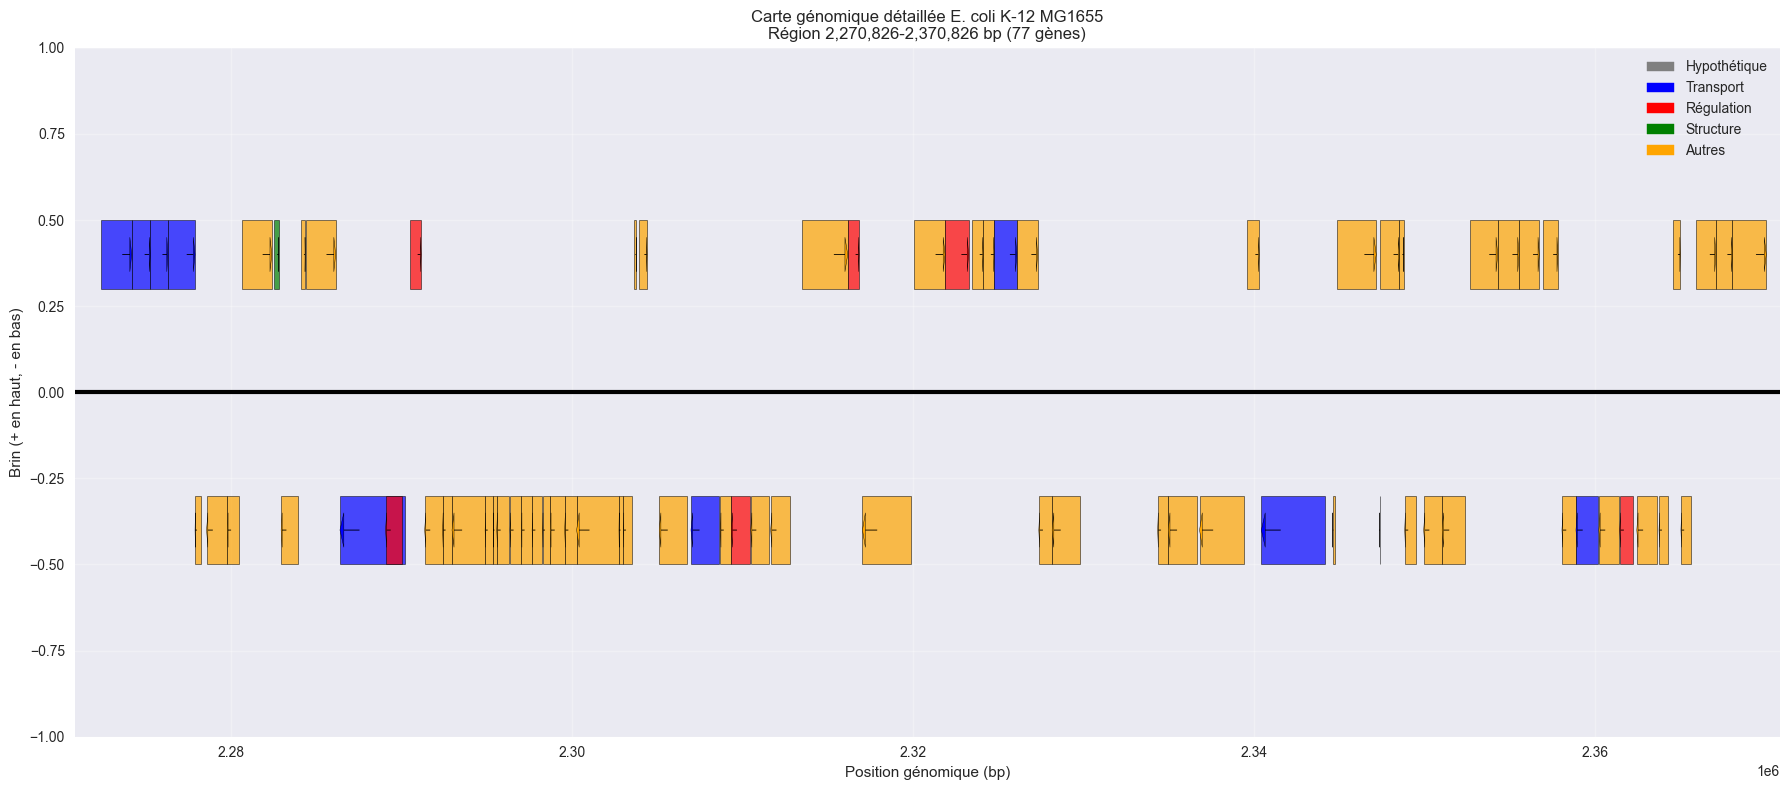

In [8]:
def carte_genomique_detaillee(record, df_proteines, start_pos=0, end_pos=100000):

    print(f"\n Création carte génomique détaillée (région {start_pos:,}-{end_pos:,} bp)")

    region_cds = df_proteines[(df_proteines['start'] >= start_pos) & (df_proteines['end'] <= end_pos)].copy()

    if len(region_cds) == 0:
        print("Aucun CDS dans cette région")
        return

    fig, ax = plt.subplots(1, 1, figsize=(18, 8))

    ax.plot([start_pos, end_pos], [0, 0], 'k-', linewidth=3, label='Génome')

    for idx, cds in region_cds.iterrows():
        start, end = cds['start'], cds['end']
        strand = cds['strand']

        if 'hypothetical' in cds['product'].lower():
            color = 'gray'
        elif any(keyword in cds['product'].lower() for keyword in ['transporter', 'permease']):
            color = 'blue'
        elif any(keyword in cds['product'].lower() for keyword in ['regulator', 'activator']):
            color = 'red'
        elif any(keyword in cds['product'].lower() for keyword in ['ribosomal', 'structural']):
            color = 'green'
        else:
            color = 'orange'

        y_pos = 0.4 if strand == '+' else -0.4
        height = 0.2

        rect = patches.Rectangle((start, y_pos - height/2), end - start, height,
                               facecolor=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)

        arrow_length = min(2000, (end - start) * 0.3)
        if strand == '+':
            ax.arrow(end - arrow_length, y_pos, arrow_length * 0.8, 0,
                    head_width=0.1, head_length=arrow_length * 0.2, fc=color, ec='black')
        else:
            ax.arrow(start + arrow_length, y_pos, -arrow_length * 0.8, 0,
                    head_width=0.1, head_length=arrow_length * 0.2, fc=color, ec='black')

        gene_name = cds['gene'] if cds['gene'] != 'Unknown' else cds['locus_tag']
        if len(region_cds) < 30:
            ax.text(start + (end - start)/2, y_pos + (0.3 if strand == '+' else -0.3),
                   gene_name, ha='center', va='bottom' if strand == '+' else 'top',
                   fontsize=8, rotation=45 if len(gene_name) > 6 else 0)

    ax.set_xlim(start_pos, end_pos)
    ax.set_ylim(-1, 1)
    ax.set_xlabel('Position génomique (bp)')
    ax.set_ylabel('Brin (+ en haut, - en bas)')
    ax.set_title(f'Carte génomique détaillée E. coli K-12 MG1655\nRégion {start_pos:,}-{end_pos:,} bp ({len(region_cds)} gènes)')

    legend_elements = [
        patches.Patch(color='gray', label='Hypothétique'),
        patches.Patch(color='blue', label='Transport'),
        patches.Patch(color='red', label='Régulation'),
        patches.Patch(color='green', label='Structure'),
        patches.Patch(color='orange', label='Autres')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig, region_cds

if 'df_proteines' in locals():
    fig_region1, region1_data = carte_genomique_detaillee(record, df_proteines, 0, 100000)

    milieu = len(record.seq) // 2
    fig_region2, region2_data = carte_genomique_detaillee(record, df_proteines, milieu - 50000, milieu + 50000)

In [9]:
def exporter_resultats_ecoli(record, df_proteines, output_dir="./ecoli_analysis_results/"):


    import os
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n💾 EXPORT DES RÉSULTATS vers {output_dir}")
    print("="*60)

    df_proteines.to_csv(f"{output_dir}ecoli_proteines_completes.csv", index=False)
    print(f" Protéines complètes exportées: ecoli_proteines_completes.csv")

    with open(f"{output_dir}ecoli_sequences_proteiques.fasta", 'w') as f:
        for _, protein in df_proteines.iterrows():
            header = f">{protein['locus_tag']}|{protein['gene']}|{protein['product']}"
            f.write(header + '\n')
            seq = protein['protein_sequence']
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + '\n')
    print(f" Séquences protéiques FASTA: ecoli_sequences_proteiques.fasta")

    with open(f"{output_dir}ecoli_sequences_cds.fasta", 'w') as f:
        for _, cds in df_proteines.iterrows():
            header = f">{cds['locus_tag']}|{cds['gene']}|{cds['start']}-{cds['end']}({cds['strand']})"
            f.write(header + '\n')
            seq = cds['dna_sequence']
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + '\n')
    print(f" Séquences CDS FASTA: ecoli_sequences_cds.fasta")

    with open(f"{output_dir}ecoli_resume_statistique.txt", 'w') as f:
        f.write("ANALYSE DU GÉNOME Escherichia coli K-12 substr. MG1655\n")
        f.write("="*60 + "\n\n")
        f.write(f"Fichier GenBank: {record.id}\n")
        f.write(f"Description: {record.description}\n")
        f.write(f"Longueur du génome: {len(record.seq):,} bp\n")
        f.write(f"Contenu GC du génome: {gc_fraction(record.seq):.2f}%\n")
        f.write(f"Topologie: {record.annotations.get('topology', 'Non spécifiée')}\n\n")

        f.write("STATISTIQUES DES PROTÉINES:\n")
        f.write(f"Nombre total de CDS: {len(df_proteines):,}\n")
        f.write(f"Longueur moyenne des protéines: {df_proteines['actual_length_aa'].mean():.1f} aa\n")
        f.write(f"Longueur médiane des protéines: {df_proteines['actual_length_aa'].median():.1f} aa\n")
        f.write(f"Protéine la plus courte: {df_proteines['actual_length_aa'].min()} aa\n")
        f.write(f"Protéine la plus longue: {df_proteines['actual_length_aa'].max()} aa\n")
        f.write(f"Poids moléculaire moyen: {df_proteines[df_proteines['molecular_weight'] > 0]['molecular_weight'].mean():.0f} Da\n")
        f.write(f"Point isoélectrique moyen: {df_proteines[df_proteines['isoelectric_point'] > 0]['isoelectric_point'].mean():.2f}\n")
        f.write(f"Contenu GC moyen des CDS: {df_proteines['gc_content'].mean():.2f}%\n")

        f.write(f"\nTOP 10 DES PLUS LONGUES PROTÉINES:\n")
        top_10 = df_proteines.nlargest(10, 'actual_length_aa')
        for i, (_, protein) in enumerate(top_10.iterrows(), 1):
            f.write(f"{i:2d}. {protein['gene']} ({protein['locus_tag']}) - {protein['actual_length_aa']} aa - {protein['product']}\n")

    print(f" Résumé statistique: ecoli_resume_statistique.txt")

    if 'categories' in globals():
        df_categories = pd.DataFrame(list(categories.items()), columns=['Catégorie', 'Nombre'])
        df_categories['Pourcentage'] = (df_categories['Nombre'] / len(df_proteines)) * 100
        df_categories.to_csv(f"{output_dir}ecoli_categories_fonctionnelles.csv", index=False)
        print(f" Catégories fonctionnelles: ecoli_categories_fonctionnelles.csv")

    # 6. Annotation GFF simplifiée
    with open(f"{output_dir}ecoli_genes.gff", 'w') as f:
        f.write("##gff-version 3\n")
        f.write(f"##sequence-region {record.id} 1 {len(record.seq)}\n")
        for _, gene in df_proteines.iterrows():
            f.write(f"{record.id}\tGenBank\tCDS\t{gene['start']}\t{gene['end']}\t.\t{gene['strand']}\t0\t")
            f.write(f"ID={gene['locus_tag']};Name={gene['gene']};Product={gene['product']}\n")
    print(f" Fichier GFF: ecoli_genes.gff")

    print(f"\n Export terminé! Tous les fichiers sont dans: {output_dir}")
    return output_dir

if 'df_proteines' in locals():
    output_directory = exporter_resultats_ecoli(record, df_proteines)


💾 EXPORT DES RÉSULTATS vers ./ecoli_analysis_results/
 Protéines complètes exportées: ecoli_proteines_completes.csv
 Séquences protéiques FASTA: ecoli_sequences_proteiques.fasta
 Séquences CDS FASTA: ecoli_sequences_cds.fasta
 Résumé statistique: ecoli_resume_statistique.txt
 Catégories fonctionnelles: ecoli_categories_fonctionnelles.csv
 Fichier GFF: ecoli_genes.gff

 Export terminé! Tous les fichiers sont dans: ./ecoli_analysis_results/


In [10]:
def analyser_operons_exemple(df_proteines, operons_connus):

    print("\n" + "="*60)
    print("ANALYSE D'OPÉRONS CONNUS")
    print("="*60)

    for operon_name, genes in operons_connus.items():
        print(f"\n Opéron {operon_name}:")

        operon_genes = []
        for gene in genes:
            matches = df_proteines[df_proteines['gene'] == gene]
            if not matches.empty:
                gene_info = matches.iloc[0]
                operon_genes.append({
                    'gene': gene_info['gene'],
                    'locus_tag': gene_info['locus_tag'],
                    'start': gene_info['start'],
                    'end': gene_info['end'],
                    'strand': gene_info['strand'],
                    'product': gene_info['product']
                })
                print(f"  {gene} ({gene_info['locus_tag']}): {gene_info['start']:,}-{gene_info['end']:,} ({gene_info['strand']})")
                print(f"     Produit: {gene_info['product']}")
            else:
                print(f"  {gene}: Non trouvé")

        if len(operon_genes) >= 2:
            operon_genes.sort(key=lambda x: x['start'])
            print(f"  Organisation spatiale:")
            for i in range(len(operon_genes)-1):
                distance = operon_genes[i+1]['start'] - operon_genes[i]['end']
                print(f"     {operon_genes[i]['gene']} -> {operon_genes[i+1]['gene']}: {distance:,} bp")

    return True

operons_ecoli = {
    'lac': ['lacI', 'lacZ', 'lacY', 'lacA'],
    'trp': ['trpL', 'trpE', 'trpD', 'trpC', 'trpB', 'trpA'],
    'ara': ['araB', 'araA', 'araD'],
    'mal': ['malE', 'malF', 'malG', 'malK'],
    'his': ['hisG', 'hisD', 'hisC', 'hisB', 'hisH', 'hisA', 'hisF', 'hisI']
}

if 'df_proteines' in locals():
    analyser_operons_exemple(df_proteines, operons_ecoli)


ANALYSE D'OPÉRONS CONNUS

 Opéron lac:
  lacI (b0345): 366,428-367,510 (-)
     Produit: DNA-binding transcriptional repressor LacI
  lacZ (b0344): 363,231-366,305 (-)
     Produit: beta-galactosidase
  lacY (b0343): 361,926-363,179 (-)
     Produit: lactose permease
  lacA (b0342): 361,249-361,860 (-)
     Produit: galactoside O-acetyltransferase
  Organisation spatiale:
     lacA -> lacY: 66 bp
     lacY -> lacZ: 52 bp
     lacZ -> lacI: 123 bp

 Opéron trp:
  trpL (b1265): 1,323,038-1,323,082 (-)
     Produit: trp operon leader peptide
  trpE (b1264): 1,321,384-1,322,946 (-)
     Produit: anthranilate synthase subunit TrpE
  trpD (b1263): 1,319,789-1,321,384 (-)
     Produit: anthranilate synthase subunit TrpD
  trpC (b1262): 1,318,427-1,319,788 (-)
     Produit: fused indole-3-glycerol phosphate synthase/phosphoribosylanthranilate isomerase
  trpB (b1261): 1,317,222-1,318,415 (-)
     Produit: tryptophan synthase subunit beta
  trpA (b1260): 1,316,416-1,317,222 (-)
     Produit: t

In [11]:
def creer_visualisation_interactive(record, df_proteines):

    print("\n CRÉATION DE VISUALISATIONS INTERACTIVES")

    fig_genome = go.Figure()

    df_sample = df_proteines.iloc[::10].copy()

    positive_strand = df_sample[df_sample['strand'] == '+']
    fig_genome.add_trace(go.Scatter(
        x=positive_strand['start'],
        y=[1] * len(positive_strand),
        mode='markers',
        marker=dict(size=8, color='red', symbol='triangle-up'),
        text=[f"Gène: {row['gene']}<br>Locus: {row['locus_tag']}<br>Produit: {row['product'][:50]}..."
              for _, row in positive_strand.iterrows()],
        hovertemplate='%{text}<extra></extra>',
        name='Brin +'
    ))

    negative_strand = df_sample[df_sample['strand'] == '-']
    fig_genome.add_trace(go.Scatter(
        x=negative_strand['start'],
        y=[-1] * len(negative_strand),
        mode='markers',
        marker=dict(size=8, color='blue', symbol='triangle-down'),
        text=[f"Gène: {row['gene']}<br>Locus: {row['locus_tag']}<br>Produit: {row['product'][:50]}..."
              for _, row in negative_strand.iterrows()],
        hovertemplate='%{text}<extra></extra>',
        name='Brin -'
    ))

    fig_genome.update_layout(
        title=f'Carte génomique interactive E. coli K-12 MG1655<br>(Échantillon: {len(df_sample):,} gènes sur {len(df_proteines):,})',
        xaxis_title='Position génomique (bp)',
        yaxis_title='Brin',
        height=400,
        yaxis=dict(tickvals=[-1, 1], ticktext=['Brin -', 'Brin +']),
        hovermode='closest'
    )

    fig_genome.show()

    valid_data = df_proteines[df_proteines['molecular_weight'] > 0].copy()

    fig_3d = go.Figure(data=[go.Scatter3d(
        x=valid_data['actual_length_aa'],
        y=valid_data['molecular_weight']/1000,
        z=valid_data['gc_content'],
        mode='markers',
        marker=dict(
            size=3,
            color=valid_data['isoelectric_point'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Point isoélectrique")
        ),
        text=[f"Gène: {row['gene']}<br>Locus: {row['locus_tag']}<br>Longueur: {row['actual_length_aa']} aa<br>MW: {row['molecular_weight']:.0f} Da<br>GC: {row['gc_content']:.1f}%<br>pI: {row['isoelectric_point']:.2f}"
              for _, row in valid_data.iterrows()],
        hovertemplate='%{text}<extra></extra>'
    )])

    fig_3d.update_layout(
        title='Analyse 3D des protéines E. coli<br>(couleur = point isoélectrique)',
        scene=dict(
            xaxis_title='Longueur (aa)',
            yaxis_title='Poids moléculaire (kDa)',
            zaxis_title='Contenu GC (%)'
        ),
        height=600
    )

    fig_3d.show()

    n_bins = 50
    bin_size = len(record.seq) // n_bins

    bins_data = []
    for i in range(n_bins):
        bin_start = i * bin_size
        bin_end = (i + 1) * bin_size
        bin_genes = df_proteines[(df_proteines['start'] >= bin_start) & (df_proteines['start'] < bin_end)]

        if len(bin_genes) > 0:
            bins_data.append({
                'bin': i,
                'position': bin_start + bin_size//2,
                'n_genes': len(bin_genes),
                'avg_length': bin_genes['actual_length_aa'].mean(),
                'avg_gc': bin_genes['gc_content'].mean(),
                'avg_mw': bin_genes[bin_genes['molecular_weight'] > 0]['molecular_weight'].mean(),
                'hypothetical_pct': (bin_genes['product'].str.contains('hypothetical', case=False).sum() / len(bin_genes)) * 100
            })

    bins_df = pd.DataFrame(bins_data)

    fig_heatmap = make_subplots(
        rows=5, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.02,
        subplot_titles=('Nombre de gènes', 'Longueur moyenne (aa)', 'Contenu GC moyen (%)',
                       'Poids moléculaire moyen (kDa)', '% Protéines hypothétiques')
    )

    fig_heatmap.add_trace(go.Scatter(x=bins_df['position'], y=bins_df['n_genes'],
                                    fill='tonexty', name='N gènes', line_color='blue'), row=1, col=1)

    fig_heatmap.add_trace(go.Scatter(x=bins_df['position'], y=bins_df['avg_length'],
                                    fill='tonexty', name='Longueur moy', line_color='red'), row=2, col=1)

    fig_heatmap.add_trace(go.Scatter(x=bins_df['position'], y=bins_df['avg_gc'],
                                    fill='tonexty', name='GC moyen', line_color='green'), row=3, col=1)

    fig_heatmap.add_trace(go.Scatter(x=bins_df['position'], y=bins_df['avg_mw']/1000,
                                    fill='tonexty', name='MW moyen', line_color='purple'), row=4, col=1)

    fig_heatmap.add_trace(go.Scatter(x=bins_df['position'], y=bins_df['hypothetical_pct'],
                                    fill='tonexty', name='% Hypothétiques', line_color='orange'), row=5, col=1)

    fig_heatmap.update_layout(
        title=f'Profil génomique E. coli K-12 MG1655<br>({n_bins} bins de {bin_size//1000:.0f} kb)',
        height=800,
        showlegend=False
    )

    fig_heatmap.update_xaxes(title_text="Position génomique (bp)", row=5, col=1)
    fig_heatmap.show()

    return fig_genome, fig_3d, fig_heatmap

if 'df_proteines' in locals():
    fig_interactive, fig_3d_interactive, fig_profile = creer_visualisation_interactive(record, df_proteines)


 CRÉATION DE VISUALISATIONS INTERACTIVES


In [12]:
def rechercher_motifs_simples(df_proteines, motifs_recherches):

    print("\n RECHERCHE DE MOTIFS PROTÉIQUES")
    print("="*60)

    resultats_motifs = {}

    for motif_name, motif_pattern in motifs_recherches.items():
        print(f"\n Recherche du motif {motif_name}: {motif_pattern}")

        trouvailles = []
        for idx, row in df_proteines.iterrows():
            seq = row['protein_sequence']
            if motif_pattern in seq:
                positions = []
                start = 0
                while True:
                    pos = seq.find(motif_pattern, start)
                    if pos == -1:
                        break
                    positions.append(pos + 1)
                    start = pos + 1

                trouvailles.append({
                    'gene': row['gene'],
                    'locus_tag': row['locus_tag'],
                    'product': row['product'],
                    'positions': positions,
                    'count': len(positions)
                })

        if trouvailles:
            print(f"  Trouvé dans {len(trouvailles)} protéines:")
            total_occurrences = sum([t['count'] for t in trouvailles])
            print(f"  Total: {total_occurrences} occurrences")

            # Top 5 des protéines avec le plus d'occurrences
            trouvailles_sorted = sorted(trouvailles, key=lambda x: x['count'], reverse=True)
            print(f"  Top 5 des protéines:")
            for i, t in enumerate(trouvailles_sorted[:5], 1):
                print(f"    {i}. {t['gene']} ({t['locus_tag']}): {t['count']} fois")
                print(f"       {t['product'][:60]}{'...' if len(t['product']) > 60 else ''}")
        else:
            print(f"  Aucune occurrence trouvée")

        resultats_motifs[motif_name] = trouvailles

    return resultats_motifs

motifs_exemple = {
    'ATP_binding': 'GXXGXGKS',
    'Zinc_finger': 'CXXCX',
    'Leucine_zipper': 'LXXXXLX',
    'Signal_peptide': 'MXXXXXLL',
    'His_tag': 'HHHHHH'
}

if 'df_proteines' in locals():
    motifs_resultats = rechercher_motifs_simples(df_proteines, motifs_exemple)


 RECHERCHE DE MOTIFS PROTÉIQUES

 Recherche du motif ATP_binding: GXXGXGKS
  Aucune occurrence trouvée

 Recherche du motif Zinc_finger: CXXCX
  Aucune occurrence trouvée

 Recherche du motif Leucine_zipper: LXXXXLX
  Aucune occurrence trouvée

 Recherche du motif Signal_peptide: MXXXXXLL
  Aucune occurrence trouvée

 Recherche du motif His_tag: HHHHHH
  Trouvé dans 1 protéines:
  Total: 2 occurrences
  Top 5 des protéines:
    1. hisL (b2018): 2 fois
       his operon leader peptide


In [13]:
def generer_rapport_final(record, df_proteines, output_dir):

    print("\nGÉNÉRATION DU RAPPORT FINAL HTML")
    print("="*60)

    html_content = f"""
    <!DOCTYPE html>
    <html lang="fr">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Analyse Génomique E. coli K-12 MG1655</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
            .header {{ background-color: #2c3e50; color: white; padding: 20px; border-radius: 10px; margin-bottom: 20px; }}
            .section {{ background-color: white; padding: 20px; margin: 20px 0; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
            .stats-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 15px; }}
            .stat-box {{ background-color: #ecf0f1; padding: 15px; border-radius: 8px; text-align: center; }}
            .stat-number {{ font-size: 2em; font-weight: bold; color: #3498db; }}
            .stat-label {{ color: #7f8c8d; margin-top: 5px; }}
            table {{ width: 100%; border-collapse: collapse; margin: 10px 0; }}
            th, td {{ border: 1px solid #ddd; padding: 12px; text-align: left; }}
            th {{ background-color: #34495e; color: white; }}
            tr:nth-child(even) {{ background-color: #f2f2f2; }}
            .highlight {{ background-color: #e74c3c; color: white; padding: 2px 5px; border-radius: 3px; }}
        </style>
    </head>
    <body>
        <div class="header">
            <h1>Analyse Génomique Complète</h1>
            <h2>Escherichia coli str. K-12 substr. MG1655</h2>
            <p><strong>ID GenBank:</strong> {record.id}</p>
            <p><strong>Description:</strong> {record.description}</p>
        </div>

        <div class="section">
            <h2>Statistiques Générales du Génome</h2>
            <div class="stats-grid">
                <div class="stat-box">
                    <div class="stat-number">{len(record.seq):,}</div>
                    <div class="stat-label">Taille du génome (bp)</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{gc_fraction(record.seq):.1f}%</div>
                    <div class="stat-label">Contenu GC</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{len(df_proteines):,}</div>
                    <div class="stat-label">Gènes codants (CDS)</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{(len(df_proteines) / len(record.seq) * 1000):.1f}</div>
                    <div class="stat-label">Densité génique (/kb)</div>
                </div>
            </div>
        </div>

        <div class="section">
            <h2>Statistiques des Protéines</h2>
            <div class="stats-grid">
                <div class="stat-box">
                    <div class="stat-number">{df_proteines['actual_length_aa'].mean():.0f}</div>
                    <div class="stat-label">Longueur moyenne (aa)</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{df_proteines[df_proteines['molecular_weight'] > 0]['molecular_weight'].mean()/1000:.0f}</div>
                    <div class="stat-label">Poids moléculaire moyen (kDa)</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{df_proteines[df_proteines['isoelectric_point'] > 0]['isoelectric_point'].mean():.1f}</div>
                    <div class="stat-label">Point isoélectrique moyen</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{len(df_proteines[df_proteines['product'].str.contains('hypothetical', case=False, na=False)]):,}</div>
                    <div class="stat-label">Protéines hypothétiques</div>
                </div>
            </div>
        </div>

        <div class="section">
            <h2>Top 15 des Plus Longues Protéines</h2>
            <table>
                <tr>
                    <th>Rang</th>
                    <th>Gène</th>
                    <th>Locus Tag</th>
                    <th>Longueur (aa)</th>
                    <th>Poids (kDa)</th>
                    <th>Produit</th>
                </tr>
    """

    top_15 = df_proteines.nlargest(15, 'actual_length_aa')
    for i, (_, protein) in enumerate(top_15.iterrows(), 1):
        html_content += f"""
                <tr>
                    <td>{i}</td>
                    <td><strong>{protein['gene']}</strong></td>
                    <td>{protein['locus_tag']}</td>
                    <td>{protein['actual_length_aa']}</td>
                    <td>{protein['molecular_weight']/1000:.1f}</td>
                    <td>{protein['product'][:60]}{'...' if len(protein['product']) > 60 else ''}</td>
                </tr>
        """

    html_content += """
            </table>
        </div>

        <div class="section">
            <h2>Répartition par Brins</h2>
            <div class="stats-grid">
    """

    plus_strand = len(df_proteines[df_proteines['strand'] == '+'])
    minus_strand = len(df_proteines[df_proteines['strand'] == '-'])

    html_content += f"""
                <div class="stat-box">
                    <div class="stat-number">{plus_strand:,}</div>
                    <div class="stat-label">Gènes brin + ({plus_strand/len(df_proteines)*100:.1f}%)</div>
                </div>
                <div class="stat-box">
                    <div class="stat-number">{minus_strand:,}</div>
                    <div class="stat-label">Gènes brin - ({minus_strand/len(df_proteines)*100:.1f}%)</div>
                </div>
            </div>
        </div>

        <div class="section">
            <h2>Fichiers Générés</h2>
            <ul>
                <li><strong>ecoli_proteines_completes.csv</strong> - Données complètes de toutes les protéines</li>
                <li><strong>ecoli_sequences_proteiques.fasta</strong> - Séquences des protéines en format FASTA</li>
                <li><strong>ecoli_sequences_cds.fasta</strong> - Séquences des CDS (ADN) en format FASTA</li>
                <li><strong>ecoli_genes.gff</strong> - Annotation des gènes en format GFF3</li>
                <li><strong>ecoli_categories_fonctionnelles.csv</strong> - Classification fonctionnelle</li>
                <li><strong>ecoli_resume_statistique.txt</strong> - Résumé textuel de l'analyse</li>
            </ul>
        </div>

        <div class="section">
            <h2>Informations sur l'Analyse</h2>
            <p><strong>Date d'analyse:</strong> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
            <p><strong>Outil utilisé:</strong> BioPython + Jupyter Notebook</p>
            <p><strong>Table de traduction:</strong> Table 11 (Code génétique bactérien)</p>
            <p><strong>Organisme:</strong> <em>Escherichia coli</em> str. K-12 substr. MG1655</p>
            <p><strong>Type de génome:</strong> {record.annotations.get('topology', 'Non spécifié')} - {record.annotations.get('molecule_type', 'Non spécifié')}</p>
        </div>

        <div style="text-align: center; margin-top: 40px; color: #7f8c8d;">
            <p>Rapport généré automatiquement par l'analyse GenBank</p>
            <p>Analyse complète du génome d'<em>E. coli</em> K-12 MG1655</p>
        </div>
    </body>
    </html>
    """

    with open(f"{output_dir}rapport_analyse_ecoli.html", 'w', encoding='utf-8') as f:
        f.write(html_content)

    print("Rapport HTML généré: rapport_analyse_ecoli.html")
    print("Ouvrez ce fichier dans un navigateur pour voir le rapport complet!")

    return f"{output_dir}rapport_analyse_ecoli.html"

if 'df_proteines' in locals() and 'output_directory' in locals():
    rapport_path = generer_rapport_final(record, df_proteines, output_directory)

print("\n" + " "*20)
print("ANALYSE TERMINÉE AVEC SUCCÈS!")
print(" "*20)
print(f"""
RÉSUMÉ DE L'ANALYSE:
├── Génome analysé: {record.id if 'record' in locals() else 'Non chargé'}
├── Taille du génome: {len(record.seq):,} bp
├── Nombre de CDS: {len(df_proteines):,}
├── Fichiers générés: 7
└── Rapport HTML: Disponible

FONCTIONNALITÉS UTILISÉES:
├──  Lecture et parsing GenBank
├──  Extraction des métadonnées
├──  Extraction des CDS
├──  Traduction ADN → Protéines
├──  Analyses statistiques
├──  Visualisations statiques (matplotlib)
├──  Visualisations interactives (plotly)
├──  Classification fonctionnelle
├──  Analyse d'opérons
├──  Recherche de motifs
├──  Export multi-format
└──  Rapport HTML complet

FICHIERS DISPONIBLES:
├── CSV: Données tabulaires
├── FASTA: Séquences biologiques
├── GFF: Annotations génomiques
├── TXT: Résumé statistique
└── HTML: Rapport complet interactif

PROCHAINES ÉTAPES POSSIBLES:
├── Analyse phylogénétique
├── Prédiction de structure
├── Analyse d'expression
├── Comparaison avec autres souches
└── Annotation fonctionnelle avancée
""")


def analyser_genbank_complet(fichier_path, output_dir="./genbank_analysis/"):

    import os
    from datetime import datetime

    print("DÉMARRAGE DE L'ANALYSE COMPLÈTE")
    print("="*50)

    print("1. Chargement du fichier GenBank...")
    try:
        record = SeqIO.read(fichier_path, "genbank")
        print(f"   Fichier chargé: {record.id}")
    except Exception as e:
        print(f"   Erreur: {e}")
        return None

    print("2. Extraction des CDS...")
    try:
        cds_list = extraire_cds_ecoli(record)
        df_proteines = pd.DataFrame(cds_list)
        print(f"  {len(cds_list)} CDS extraites")
    except Exception as e:
        print(f"   Erreur CDS: {e}")
        return None

    print("3. Analyses statistiques...")
    stats = {
        'genome_length': len(record.seq),
        'gc_content': gc_fraction(record.seq),
        'n_cds': len(df_proteines),
        'avg_protein_length': df_proteines['actual_length_aa'].mean(),
        'gene_density': len(df_proteines) / len(record.seq) * 1000
    }

    print("4. Export des résultats...")
    os.makedirs(output_dir, exist_ok=True)

    df_proteines.to_csv(f"{output_dir}proteines_completes.csv", index=False)

    with open(f"{output_dir}sequences_proteiques.fasta", 'w') as f:
        for _, protein in df_proteines.iterrows():
            f.write(f">{protein.get('locus_tag', 'Unknown')}|{protein.get('gene', 'Unknown')}\n")
            seq = protein.get('protein_sequence', '')
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + '\n')

    with open(f"{output_dir}resume_analyse.txt", 'w') as f:
        f.write(f"ANALYSE GENBANK - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*50 + "\n")
        f.write(f"Fichier: {os.path.basename(fichier_path)}\n")
        f.write(f"ID: {record.id}\n")
        f.write(f"Longueur: {stats['genome_length']:,} bp\n")
        f.write(f"GC: {stats['gc_content']:.2f}%\n")
        f.write(f"CDS: {stats['n_cds']:,}\n")
        f.write(f"Longueur protéine moyenne: {stats['avg_protein_length']:.1f} aa\n")
        f.write(f"Densité génique: {stats['gene_density']:.1f} gènes/kb\n")

    print("ANALYSE TERMINÉE!")
    print(f"Résultats dans: {output_dir}")

    return {
        'record': record,
        'dataframe': df_proteines,
        'statistics': stats,
        'output_directory': output_dir
    }


GÉNÉRATION DU RAPPORT FINAL HTML
Rapport HTML généré: rapport_analyse_ecoli.html
Ouvrez ce fichier dans un navigateur pour voir le rapport complet!

                    
ANALYSE TERMINÉE AVEC SUCCÈS!
                    

RÉSUMÉ DE L'ANALYSE:
├── Génome analysé: NC_000913.3
├── Taille du génome: 4,641,652 bp
├── Nombre de CDS: 4,315
├── Fichiers générés: 7
└── Rapport HTML: Disponible

FONCTIONNALITÉS UTILISÉES:
├──  Lecture et parsing GenBank
├──  Extraction des métadonnées
├──  Extraction des CDS
├──  Traduction ADN → Protéines
├──  Analyses statistiques
├──  Visualisations statiques (matplotlib)
├──  Visualisations interactives (plotly)
├──  Classification fonctionnelle
├──  Analyse d'opérons
├──  Recherche de motifs
├──  Export multi-format
└──  Rapport HTML complet

FICHIERS DISPONIBLES:
├── CSV: Données tabulaires
├── FASTA: Séquences biologiques
├── GFF: Annotations génomiques
├── TXT: Résumé statistique
└── HTML: Rapport complet interactif

PROCHAINES ÉTAPES POSSIBLES:
├── Ana